# GBP/JPY — Day-of-Week & Session Analysis

Interactive companion to [`REPORT.md`](REPORT.md). Data provenance: [`data/README.md`](data/README.md).

The heavy lifting lives in [`analysis.py`](analysis.py); this notebook re-runs it and walks through the results so you can poke at any table.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis  # local module: loaders + stats

DOW = analysis.DOW
df5 = analysis.load_daily_5y()   # stitched FRED + currency-api daily closes, Aug 2021 - Aug 2026
d1  = analysis.load_d1()         # Dukascopy daily OHLC 2012-2022 (prices /1000, pips = x100)
h1  = analysis.load_h1()         # Dukascopy hourly, converted to London time
print(f"daily 5y: {len(df5)} rows {df5.date.min().date()} .. {df5.date.max().date()}")
print(f"d1: {len(d1)} rows, h1: {len(h1)} rows (ends {h1.ldn.max()})")

daily 5y: 1259 rows 2021-08-03 .. 2026-08-06
d1: 2400 rows, h1: 56636 rows (ends 2022-03-04 21:00:00)


## 1. Five-year day-of-week stats (close-to-close)

In [2]:
stats = pd.DataFrame({d: analysis.weekday_stats(df5[df5.dow == i]) for i, d in enumerate(DOW)}).T
stats

,n,mean_ret,median_ret,std_ret,pct_up,mean_abs_ret,t_stat
Mon,231.0,0.1153,0.1388,0.5804,61.5,0.4479,3.02
Tue,260.0,0.0645,0.0552,0.6267,56.5,0.4297,1.66
Wed,259.0,0.0515,0.0892,0.5564,57.9,0.4169,1.49
Thu,253.0,-0.0644,-0.0245,0.6761,45.1,0.4891,-1.51
Fri,256.0,-0.0252,0.0195,0.6480,52.7,0.4598,-0.62


In [3]:
# year-by-year consistency: mean return per weekday per calendar year
df5.pivot_table(index="year", columns="dow", values="ret", aggfunc="mean").round(3).set_axis(DOW, axis=1)

,Mon,Tue,Wed,Thu,Fri
year,,,,,
2021,0.056,0.037,0.125,0.046,-0.152
2022,0.110,0.124,0.042,-0.121,-0.097
2023,0.222,0.016,-0.003,-0.156,0.188
2024,0.048,0.076,0.131,0.006,-0.073
2025,0.108,0.051,0.033,-0.006,-0.045
2026,0.118,0.067,0.010,-0.096,-0.063


**Monday is positive in all six years** (61.5% up days, t≈3.0); Thursday is the only day negative in both this
series and the independent 2017–2022 OHLC data below. See the report for why this still deserves skepticism
(regime dependence, multiple comparisons).

## 2. Ranges and tails by weekday (Dukascopy OHLC)

In [4]:
rec = d1[d1.year >= 2017]
pd.DataFrame({d: {
    "mean_range_pips": rec[rec.dow == i].range_pips.mean(),
    "p95_range_pips": rec[rec.dow == i].range_pips.quantile(.95),
    "pct_up": (rec[rec.dow == i].ret > 0).mean() * 100,
    "worst_day_%": rec[rec.dow == i].ret.min(),
} for i, d in enumerate(DOW)}).T.round(1)

,mean_range_pips,p95_range_pips,pct_up,worst_day_%
Mon,122.0,220.4,59.7,-2.2
Tue,133.3,239.9,54.5,-1.6
Wed,126.5,224.1,54.9,-3.6
Thu,136.8,277.9,45.9,-1.7
Fri,128.8,246.4,45.1,-1.9


## 3. Volatility by weekday × hour (London time)

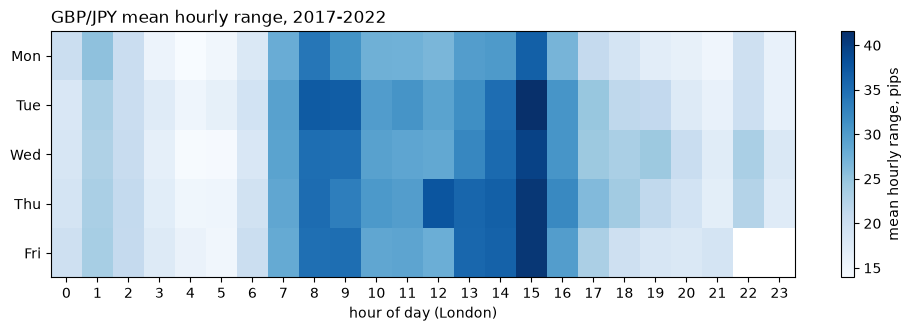

In [5]:
heat = rec_h = h1[h1.year >= 2017].pivot_table(index="dow", columns="hour", values="range_pips", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 3.2))
im = ax.imshow(heat, cmap="Blues", aspect="auto")
ax.set_yticks(range(5), DOW); ax.set_xticks(range(24))
ax.set_xlabel("hour of day (London)"); fig.colorbar(im, label="mean hourly range, pips")
ax.set_title("GBP/JPY mean hourly range, 2017-2022", loc="left")
plt.show()

In [6]:
# session net drift per weekday, full 2012-2022 sample (pips)
sess = analysis.h1_analysis(h1)["sessions"]
pd.DataFrame({s: {d: v["mean_net_pips"] for d, v in days.items()} for s, days in sess.items()})

,Asia (00-08),London AM (08-12),London/NY overlap (12-17),NY late (17-22)
Mon,-1.1,-1.0,0.7,-0.2
Tue,-0.2,-0.9,0.2,1.7
Wed,-0.3,2.7,4.5,1.8
Thu,-0.8,2.1,-0.7,2.0
Fri,-5.8,-5.8,-3.6,-5.4


Friday drifts **negative in every session** over 10 years. Note these are single-digit-pip averages —
bias-grade information, not standalone trades, given 2–4 pip spreads.

## 4. Naive backtests (in-sample vs out-of-sample)

In [7]:
bt = {f"{DOW[d]} {s}": analysis.backtest_daily_direction(df5, d, s)
      for d in range(5) for s in ("long", "short")}
rows = {k: {("IS", m): v["in_sample"][m] for m in ("win_rate", "sharpe_ann")} |
           {("OOS", m): v["out_of_sample"][m] for m in ("win_rate", "sharpe_ann")}
        for k, v in bt.items()}
pd.DataFrame(rows).T

IS                 OOS           
          win_rate sharpe_ann win_rate sharpe_ann
Mon long      60.8       1.35     62.8       1.65
Mon short     39.2      -1.35     37.2      -1.65
Tue long      57.9       0.70     53.7       0.93
Tue short     42.1      -0.70     46.3      -0.93
Wed long      59.1       0.79     55.4       0.37
Wed short     40.9      -0.79     44.6      -0.37
Thu long      45.3      -0.73     44.4      -0.58
Thu short     54.7       0.73     55.6       0.58
Fri long      53.4      -0.13     51.2      -0.76
Fri short     46.6       0.13     48.8       0.76

Monday-long is the only rule that is strong and improves out-of-sample (2025–26: 62.8% win rate,
annualized Sharpe 1.65 before costs). Full caveats in `REPORT.md` — read them before trading this.